In [14]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

run = 'a_20260401_075852'

# Set to a CSV path string to force a specific file, e.g. '../results/my_file.csv'.
csv_file = f'../results/{run}/summary_{run}.csv'

results_candidates = [Path('results'), Path('../results')]
results_dir = next((p for p in results_candidates if p.exists() and p.is_dir()), None)
if results_dir is None:
    searched = [str(p.resolve()) for p in results_candidates]
    raise FileNotFoundError(f"Results folder not found. Searched: {searched}")

if csv_file is None:
    csv_candidates = sorted(results_dir.rglob('*.csv'))
    if not csv_candidates:
        raise FileNotFoundError(f"No .csv files found inside {results_dir.resolve()}")
    csv_file = str(csv_candidates[0])

print(f"Using CSV file: {csv_file}")
df = pd.read_csv(csv_file)

required_columns = ['instance', 'algorithm', 'objective_mean', 'exec_time_mean']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

best_objectives_candidates = [
    Path('best_solutions') / 'best_objectives.csv',
    Path('../best_solutions') / 'best_objectives.csv',
]
best_objectives_path = next((p for p in best_objectives_candidates if p.exists()), None)
if best_objectives_path is None:
    searched = [str(p.resolve()) for p in best_objectives_candidates]
    raise FileNotFoundError(f"Best objectives file not found. Searched: {searched}")

best_df = pd.read_csv(best_objectives_path)
if 'instance' not in best_df.columns or 'best_objective' not in best_df.columns:
    raise ValueError("best_objectives.csv must contain columns: instance, best_objective")

if 'dataset' in df.columns and 'dataset' in best_df.columns:
    merge_columns = ['dataset', 'instance']
else:
    merge_columns = ['instance']

df = df.merge(best_df[merge_columns + ['best_objective']], on=merge_columns, how='left')
ordered_columns = [col for col in df.columns if col != 'best_objective'] + ['best_objective']
df = df[ordered_columns]

df.head()

Using CSV file: ../results/a_20260401_075852/summary_a_20260401_075852.csv


,dataset,algorithm,instance,total_runs,feasible_runs,timed_out_runs,objective_mean,objective_median,objective_mode,objective_min,...,aisles_variance,aisles_std_dev,exec_time_mean,exec_time_median,exec_time_mode,exec_time_min,exec_time_max,exec_time_variance,exec_time_std_dev,best_objective
0,a,aisle_first,instance_0001.txt,10,10,0,12.00,12.00,12.00,12.00,...,0.0,0.0,0.003216,0.003063,0.002881,0.002755,0.004062,1.840997e-07,0.000429,15.00
1,a,aisle_first,instance_0002.txt,10,10,0,2.00,2.00,2.00,2.00,...,0.0,0.0,0.000943,0.000699,0.000703,0.000613,0.001990,2.585527e-07,0.000508,2.00
2,a,aisle_first,instance_0003.txt,10,10,0,8.25,8.25,8.25,8.25,...,0.0,0.0,0.003302,0.003095,0.003003,0.002796,0.004275,2.368925e-07,0.000487,12.00
3,a,aisle_first,instance_0006.txt,10,10,0,691.00,691.00,691.00,691.00,...,0.0,0.0,0.337342,0.337348,0.288888,0.288888,0.386154,1.010820e-03,0.031793,691.00
4,a,aisle_first,instance_0007.txt,10,10,0,284.80,284.80,284.80,284.80,...,0.0,0.0,0.226319,0.229479,0.246867,0.192760,0.256160,4.220793e-04,0.020545,392.25


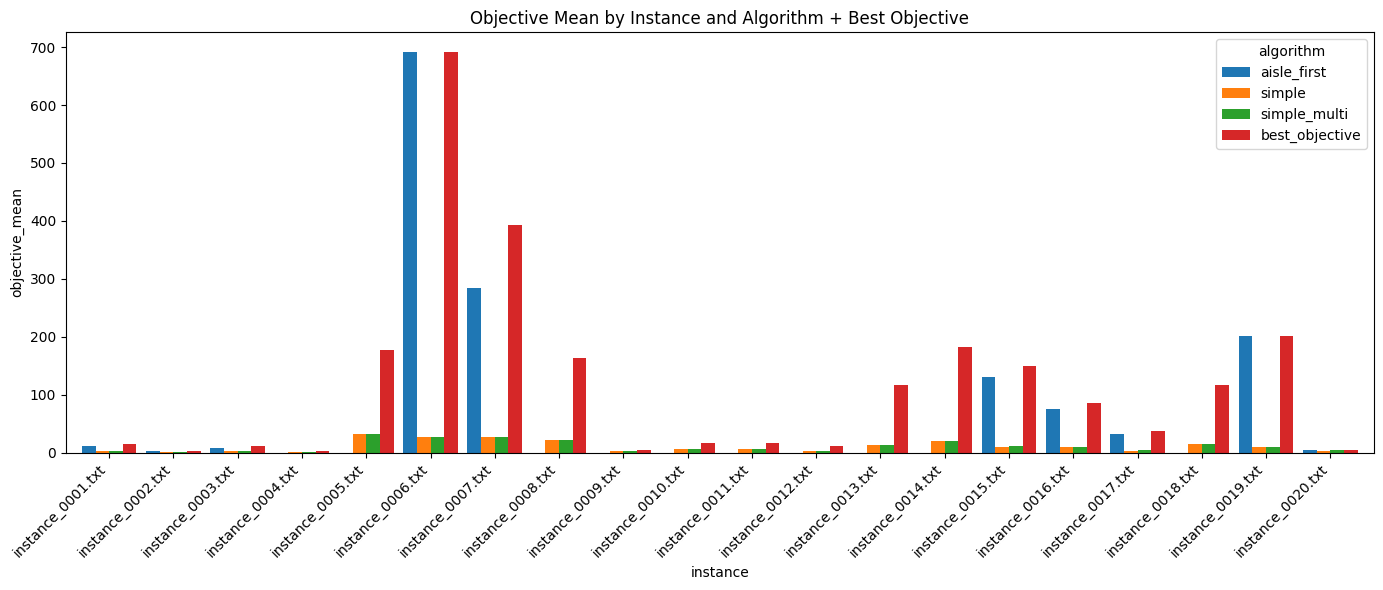

In [15]:
objective_plot = (
    df.pivot_table(
        index='instance',
        columns='algorithm',
        values='objective_mean',
        aggfunc='mean'
    )
    .sort_index()
    .fillna(0)
)

best_objective_by_instance = (
    df[['instance', 'best_objective']]
    .drop_duplicates(subset='instance')
    .set_index('instance')['best_objective']
)
objective_plot['best_objective'] = objective_plot.index.to_series().map(best_objective_by_instance).fillna(0)

ax = objective_plot.plot(kind='bar', figsize=(14, 6), width=0.85)
ax.set_xlabel('instance')
ax.set_ylabel('objective_mean')
ax.set_title('Objective Mean by Instance and Algorithm + Best Objective')
ax.legend(title='algorithm')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

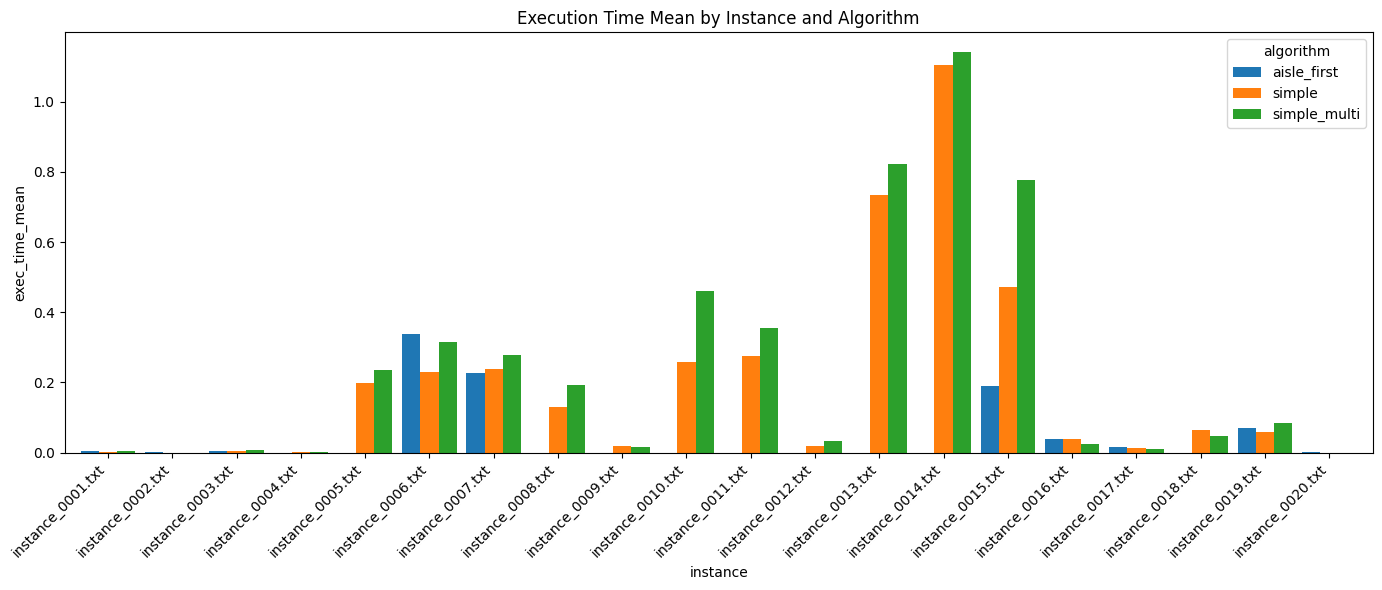

In [16]:
exec_time_plot = (
    df.pivot_table(
        index='instance',
        columns='algorithm',
        values='exec_time_mean',
        aggfunc='mean'
    )
    .sort_index()
    .fillna(0)
)

ax = exec_time_plot.plot(kind='bar', figsize=(14, 6), width=0.85)
ax.set_xlabel('instance')
ax.set_ylabel('exec_time_mean')
ax.set_title('Execution Time Mean by Instance and Algorithm')
ax.legend(title='algorithm')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
ranking_dataset_param = None  # e.g., 'a', 'b', 'x' or None for all datasets

ranking_base = df[["instance", "algorithm", "objective_mean", "exec_time_mean"]].copy()
if ranking_dataset_param is not None and "dataset" in df.columns:
    ranking_base = df[df["dataset"] == ranking_dataset_param][
        ["instance", "algorithm", "objective_mean", "exec_time_mean"]
    ].copy()

if ranking_base.empty:
    raise ValueError(f"No rows found for dataset={ranking_dataset_param!r}")


def build_final_ranking(base_df: pd.DataFrame, metric_column: str, ascending: bool) -> pd.DataFrame:
    metric_df = base_df.dropna(subset=[metric_column]).copy()
    if metric_df.empty:
        raise ValueError(f"No non-null values found for metric {metric_column!r}.")

    metric_df["N"] = metric_df.groupby("instance")["algorithm"].transform("nunique")
    metric_df["rank_class"] = metric_df.groupby("instance")[metric_column].rank(
        method="min", ascending=ascending
    ).astype(int)
    metric_df["score"] = metric_df["N"] - metric_df["rank_class"]

    final_ranking = (
        metric_df.groupby("algorithm", as_index=False)["score"]
        .agg(total_score="sum", average_score="mean", instances_count="count")
        .sort_values(["total_score", "average_score", "algorithm"], ascending=[False, False, True])
        .reset_index(drop=True)
    )
    final_ranking["final_rank"] = final_ranking["total_score"].rank(
        method="min", ascending=False
    ).astype(int)

    return final_ranking[
        ["final_rank", "algorithm", "total_score", "average_score", "instances_count"]
    ]


objective_ranking = build_final_ranking(
    ranking_base, metric_column="objective_mean", ascending=False
)
exec_time_ranking = build_final_ranking(
    ranking_base, metric_column="exec_time_mean", ascending=True
)

print(f"Dataset filter for ranking: {ranking_dataset_param!r}")
print("\nOBJECTIVE_MEAN - FINAL RANKING")
display(objective_ranking)
print("\nEXEC_TIME_MEAN - FINAL RANKING")
display(exec_time_ranking)

Dataset filter for ranking: None

OBJECTIVE_MEAN - FINAL RANKING


,final_rank,algorithm,total_score,average_score,instances_count
0,1,aisle_first,20,2.00,10
1,2,simple_multi,19,0.95,20
2,3,simple,2,0.10,20



EXEC_TIME_MEAN - FINAL RANKING


,final_rank,algorithm,total_score,average_score,instances_count
0,1,simple,20,1.00,20
1,2,simple_multi,13,0.65,20
2,3,aisle_first,7,0.70,10
